In [41]:
import pandas as pd

data = pd.read_csv("train.csv")
data.head()
data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [42]:
print(data.isna().sum())
print(data.dtypes)
data.value_counts()
data.columns
print(data.head())

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64
id                    int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object
   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc         7.91              98.8              no   
1   1   18   other  diploma         4.95              94.8             yes   
2   2   20  female     b.sc         4.68              92.6             yes   
3   3   19 

Medir skewness dos dados numéricos
Conclusão: os dados são bastantes simétricos, loogo a skewness não oferece muita informação

In [43]:
data= data.drop(columns="id")
skewness = data.skew(numeric_only=True)
print(skewness)

age                -0.023878
study_hours         0.008931
class_attendance   -0.095832
sleep_hours        -0.039986
exam_score         -0.048273
dtype: float64


Medir kurtosis dos dados numéricos: Podemos concluir que os dados são bastante achatados pois tdos os valores são menores que 0

In [44]:
kurtosis = data.kurt(numeric_only=True)
print(kurtosis)

age                -1.204216
study_hours        -1.211528
class_attendance   -1.189059
sleep_hours        -1.222221
exam_score         -0.618958
dtype: float64


Distribuição das nt

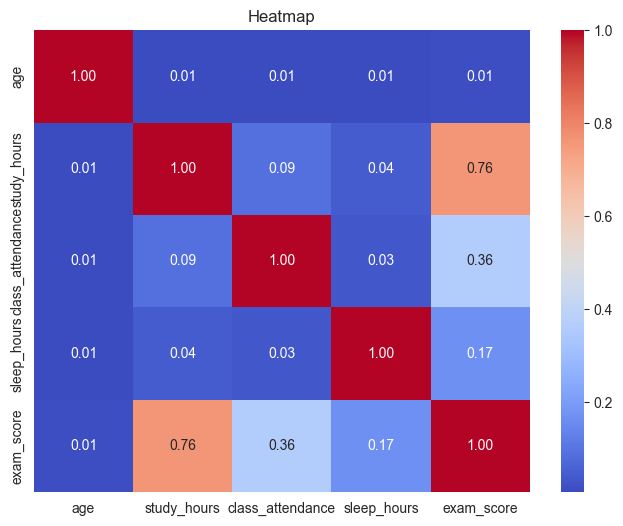

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = data.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Heatmap")
plt.show()

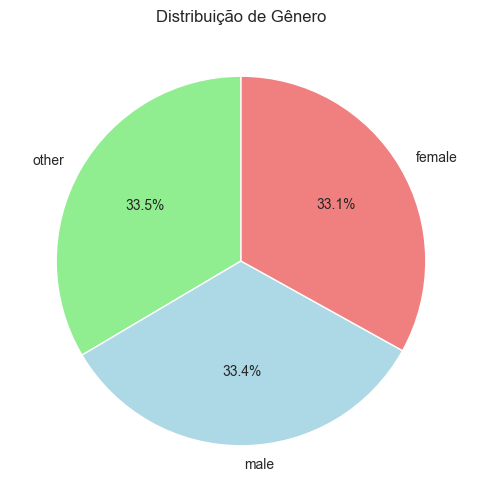

In [46]:
gender_counts = data['gender'].value_counts() # nums para piechart
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors = ["lightgreen", "lightblue", "lightcoral"]
)
plt.title("Distribuição de Gênero")
plt.show()

In [47]:
def categorize_data(df):
    df_copy = df.copy()

    # Idade
    df_copy['age_interval'] = pd.cut(df_copy['age'],
                                     bins=[17,19,21,23,25,100],
                                     labels=["18-19","20-21","22-23","24-25","26+"])

    # Horas de estudo
    df_copy['study_hours_interval'] = pd.cut(df_copy['study_hours'],
                                             bins=[-1,1,3,5,7,100],
                                             labels=["0-1h","2-3h","4-5h","6-7h","8h ou mais"])

    # Presença em aula
    df_copy['class_attendance_interval'] = pd.cut(df_copy['class_attendance'],
                                                  bins=[-1,20,40,60,80,100],
                                                  labels=["0-20%","21-40%","41-60%","61-80%","81-100%"])

    # Horas de sono
    df_copy['sleep_hours_interval'] = pd.cut(df_copy['sleep_hours'],
                                             bins=[-1,4,6,8,10,100],
                                             labels=["0-4h","5-6h","7-8h","9-10h","11h ou mais"])

    # Nota do exame
    df_copy['exam_score_interval'] = pd.cut(df_copy['exam_score'],
                                            bins=[-1,49,59,69,79,89,100],
                                            labels=["0-49","50-59","60-69","70-79","80-89","90-100"])
    return df_copy

# Aplicando a função
data_intervals = categorize_data(data)

# Visualizando o resultado
print(data_intervals.head())

   age  gender   course  study_hours  class_attendance internet_access  \
0   21  female     b.sc         7.91              98.8              no   
1   18   other  diploma         4.95              94.8             yes   
2   20  female     b.sc         4.68              92.6             yes   
3   19    male     b.sc         2.00              49.5             yes   
4   23    male      bca         7.65              86.9             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0          4.9       average  online videos             low            easy   
1          4.7          poor     self-study          medium        moderate   
2          5.8          poor       coaching            high        moderate   
3          8.3       average    group study            high        moderate   
4          9.6          good     self-study            high            easy   

   exam_score age_interval study_hours_interval class_attendance_interval  \
0  

C:\Users\maria\AppData\Local\Temp\ipykernel_19616\3874816542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


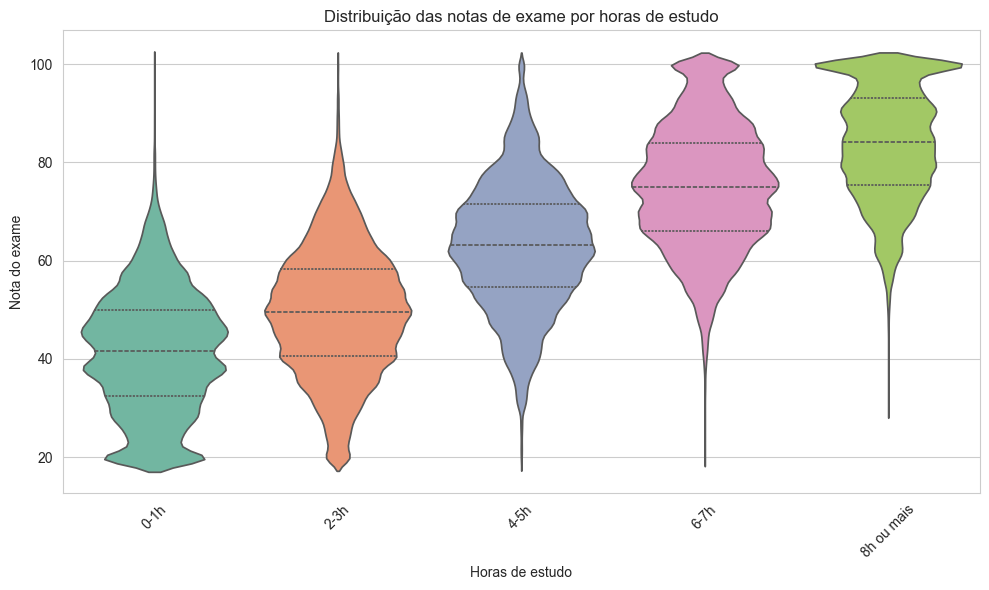

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Certifique-se de que as colunas de intervalos já existem
# 'study_hours_interval' e 'exam_score_interval' do passo anterior

plt.figure(figsize=(10,6))
sns.violinplot(
    x="study_hours_interval",       # usando intervalos de horas de estudo
    y="exam_score",                 
    data=data_intervals,
    inner="quartile",             
    palette="Set2"
)
plt.title("Distribuição das notas de exame por horas de estudo")
plt.xlabel("Horas de estudo")
plt.ylabel("Nota do exame")
plt.xticks(rotation=45)             # gira os rótulos do eixo x para melhor visualização
plt.tight_layout()
plt.show()

Lolipop Chart

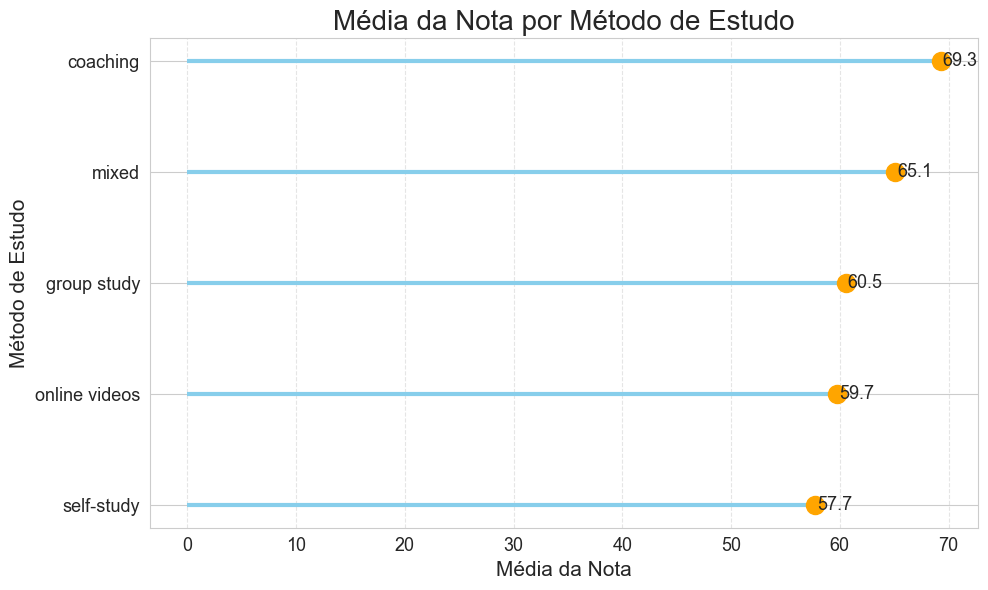

In [49]:
import matplotlib.pyplot as plt

media_metodo = data_intervals.groupby("study_method")["exam_score"].mean().sort_values()

plt.figure(figsize=(10, 6))

plt.hlines(y=media_metodo.index, xmin=0, xmax=media_metodo.values, color='skyblue', linewidth=3)
plt.plot(media_metodo.values, media_metodo.index, "o", color='orange', markersize=13)

# Valores ao lado do ponto
for i, v in enumerate(media_metodo.values):
    plt.text(v + 0.2, i, f"{v:.1f}", va='center', fontsize=13)

plt.xlabel("Média da Nota", size = 15)
plt.ylabel("Método de Estudo", size=15)
plt.title("Média da Nota por Método de Estudo", size=20)
plt.xticks(fontsize=13)  # números do eixo X
plt.yticks(fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Spider chart

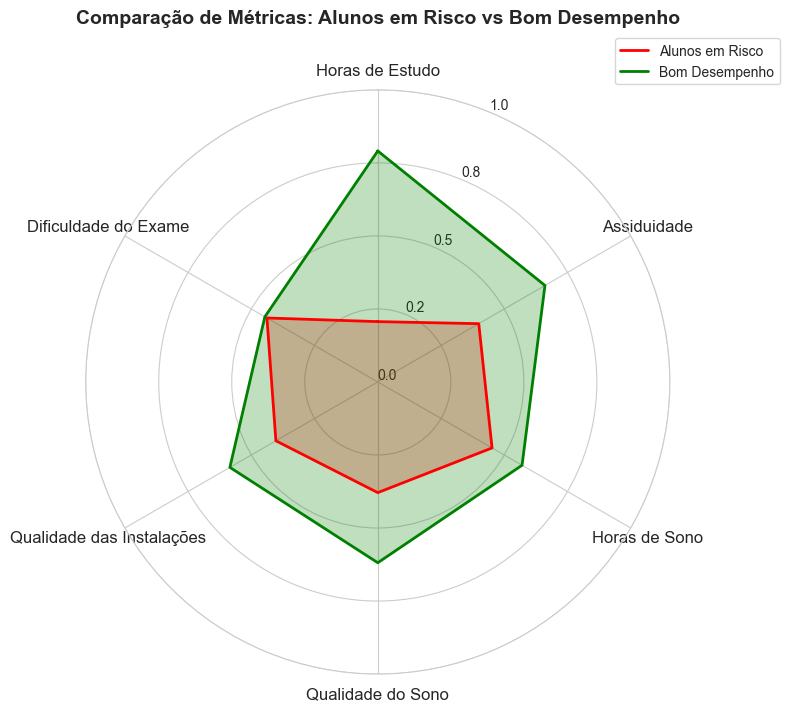

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Function to map categorical variables to numeric
def encode_categories(df):
    sleep_quality_map = {'poor': 1, 'average': 2, 'good': 3}
    exam_difficulty_map = {'easy': 1, 'moderate': 2, 'hard': 3}
    facility_rating_map = {'low': 1, 'medium': 2, 'high': 3}
    
    df['sleep_quality_num'] = df['sleep_quality'].map(sleep_quality_map)
    df['exam_difficulty_num'] = df['exam_difficulty'].map(exam_difficulty_map)
    df['facility_rating_num'] = df['facility_rating'].map(facility_rating_map)
    
    return df

# Copy dataframe
df = data_intervals.copy()

# Encode categorical variables
df = encode_categories(df)

# Metrics
metrics = [
    'study_hours',
    'class_attendance',
    'sleep_hours',
    'sleep_quality_num',
    'facility_rating_num',
    'exam_difficulty_num'
]

# Normalizar os dados (ESSENCIAL para radar)
scaler = MinMaxScaler()
df[metrics] = scaler.fit_transform(df[metrics])

# Definir grupos
aluno_risco = df[df['exam_score'] < 50]
bom_desempenho = df[df['exam_score'] >= 75]

# Médias
mean_risco = aluno_risco[metrics].mean().fillna(0)
mean_bom = bom_desempenho[metrics].mean().fillna(0)

# Preparar radar
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # fechar círculo

mean_risco_values = mean_risco.tolist()
mean_risco_values += mean_risco_values[:1]

mean_bom_values = mean_bom.tolist()
mean_bom_values += mean_bom_values[:1]

labels_map = {
    'study_hours': 'Horas de Estudo',
    'class_attendance': 'Assiduidade',
    'sleep_hours': 'Horas de Sono',
    'sleep_quality_num': 'Qualidade do Sono',
    'facility_rating_num': 'Qualidade das Instalações',
    'exam_difficulty_num': 'Dificuldade do Exame'
}
# Plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Ajustes do eixo
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Plot risco
ax.plot(angles, mean_risco_values, color='red', linewidth=2, label='Alunos em Risco')
ax.fill(angles, mean_risco_values, color='red', alpha=0.25)

# Plot bom desempenho
ax.plot(angles, mean_bom_values, color='green', linewidth=2, label='Bom Desempenho')
ax.fill(angles, mean_bom_values, color='green', alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels([labels_map[m] for m in metrics], fontsize=12)

# Escala fixa (0–1 por causa da normalização)
ax.set_yticks(np.linspace(0, 1, 5))
ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0, 1, 5)], fontsize=10)
ax.set_ylim(0, 1)

# Título e legenda
plt.title(
    "Comparação de Métricas: Alunos em Risco vs Bom Desempenho",
    fontsize=14,
    fontweight='bold',
    y=1.1
)

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()


Identificação de Outliers

In [11]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import pandas as pd

cols = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
lof_df = data_intervals[cols].copy()
# NORMALIZAR
scaler = StandardScaler()
X_scaled = scaler.fit_transform(lof_df)

# aplicar LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_scaled)

# adicionar resultados
lof_df["outlier"] = y_pred
lof_df["lof_score"] = lof.negative_outlier_factor_

# filtrar outliers
outliers = lof_df[lof_df["outlier"] == -1]

# outputs
print("Número de outliers:", len(outliers))
print("\nOutliers encontrados:\n")
print(outliers.sort_values(by="lof_score"))  # mais extremos primeiro

Número de outliers: 31500

Outliers encontrados:

        age  study_hours  class_attendance  sleep_hours  exam_score  outlier  \
258607   17         0.80              65.3          9.5        99.9       -1   
615603   19         0.89              67.8          4.3        92.7       -1   
47775    17         0.75              89.4          4.1        88.8       -1   
497661   24         6.81              40.6          4.1        25.0       -1   
560007   17         7.44              97.6          6.4        47.8       -1   
...     ...          ...               ...          ...         ...      ...   
479077   18         1.52              99.4          5.2        42.7       -1   
578425   21         3.17              71.0          4.1        32.4       -1   
182527   18         2.20              92.5          6.2        80.8       -1   
549132   21         6.05              64.7          8.2        53.5       -1   
74684    18         2.62              71.6          6.3        34.4   

In [12]:
print(data_intervals.describe().round(2))
data_intervals.dtypes
data_intervals.head()
data_intervals.columns

             age  study_hours  class_attendance  sleep_hours  exam_score
count  630000.00    630000.00         630000.00    630000.00   630000.00
mean       20.55         4.00             71.99         7.07       62.51
std         2.26         2.36             17.43         1.74       18.92
min        17.00         0.08             40.60         4.10       19.60
25%        19.00         1.97             57.00         5.60       48.80
50%        21.00         4.00             72.60         7.10       62.60
75%        23.00         6.05             87.20         8.60       76.30
max        24.00         7.91             99.40         9.90      100.00


Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score', 'age_interval',
       'study_hours_interval', 'class_attendance_interval',
       'sleep_hours_interval', 'exam_score_interval'],
      dtype='object')

In [13]:
data_intervals.duplicated().sum()

np.int64(0)

Multicolinearidade

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data_intervals[cols].drop(columns="exam_score")
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

            feature        VIF
0               age  25.059881
1       study_hours   3.870725
2  class_attendance  15.892231
3       sleep_hours  15.271241


Teste de independencia para variaveis categóricas


In [15]:
from scipy.stats import chi2_contingency

categorical_cols = ['gender', 'course', 'study_method', 'internet_access']
for i in range(len(categorical_cols)):
    for j in range(i+1, len(categorical_cols)):
        contingency = pd.crosstab(data_intervals[categorical_cols[i]],
                                  data_intervals[categorical_cols[j]])
        chi2, p, _, _ = chi2_contingency(contingency)
        print(f"{categorical_cols[i]} vs {categorical_cols[j]}: p-value = {p:.4f}")

gender vs course: p-value = 0.0000
gender vs study_method: p-value = 0.0000
gender vs internet_access: p-value = 0.0583
course vs study_method: p-value = 0.0000
course vs internet_access: p-value = 0.0002
study_method vs internet_access: p-value = 0.0000


Como vif > 5 para todas, existe alta multicolinearidade, algo a ter em conta nos modelos de previsão

Identificar desequilíbrios nas variáveis categóricas

In [16]:
categorical_cols = ['gender', 'course', 'study_method', 'internet_access']

for col in categorical_cols:
    print(f"=== {col} ===")
    print(data_intervals[col].value_counts())            # contagem absoluta
    print(data_intervals[col].value_counts(normalize=True))  # percentual
    print("\n")

=== gender ===
gender
other     211097
male      210593
female    208310
Name: count, dtype: int64
gender
other     0.335075
male      0.334275
female    0.330651
Name: proportion, dtype: float64


=== course ===
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64
course
b.tech     0.208311
b.sc       0.177070
b.com      0.176083
bca        0.140827
bba        0.120070
ba         0.098395
diploma    0.079244
Name: proportion, dtype: float64


=== study_method ===
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64
study_method
coaching         0.209043
self-study       0.208144
mixed            0.195375
group study      0.195252
online videos    0.192186
Name: proportion, dtype: float64


=== internet_access ===
internet_access
yes    579423
no      50577
Name: count, dtype: 

C:\Users\maria\AppData\Local\Temp\ipykernel_19616\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


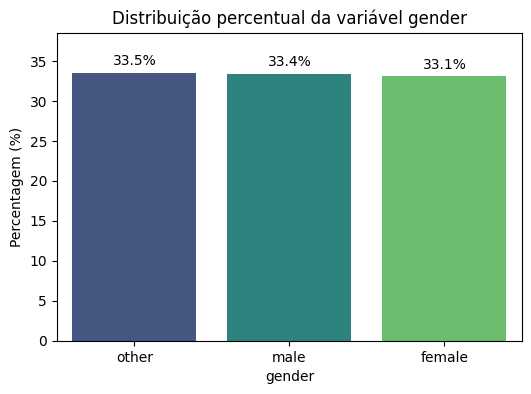

C:\Users\maria\AppData\Local\Temp\ipykernel_19616\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


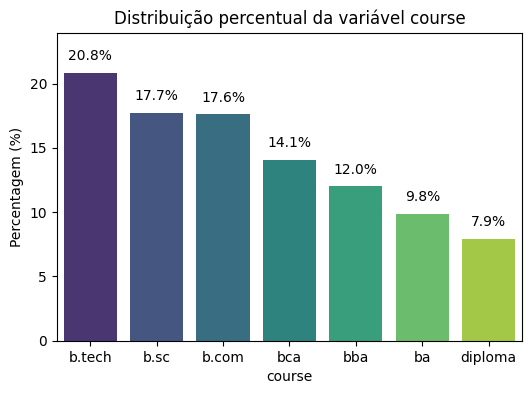

C:\Users\maria\AppData\Local\Temp\ipykernel_19616\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


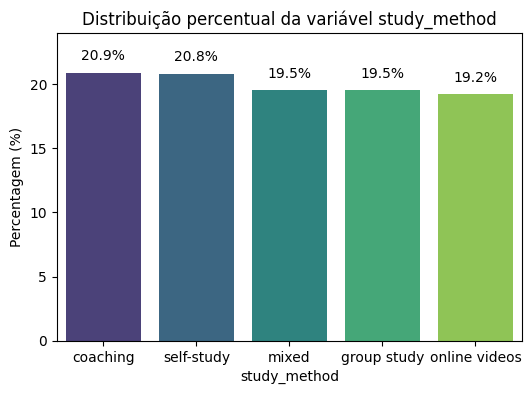

C:\Users\maria\AppData\Local\Temp\ipykernel_19616\3519168840.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


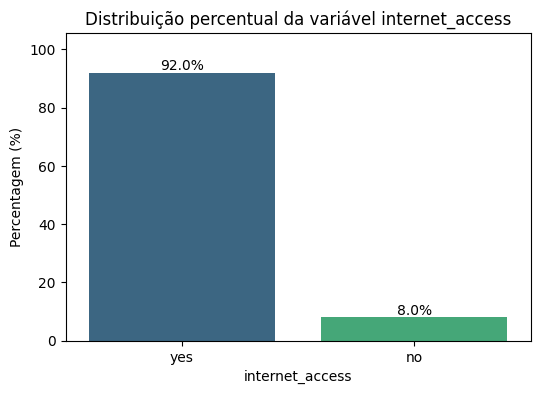

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['gender', 'course', 'study_method', 'internet_access']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    
    # Calcular porcentagem
    counts = data_intervals[col].value_counts(normalize=True) * 100
    
    # Gráfico de barras
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    
    # Adicionar labels em porcentagem
    for i, val in enumerate(counts.values):
        plt.text(i, val + 1, f"{val:.1f}%", ha='center')
    
    plt.ylabel("Percentagem (%)")
    plt.title(f"Distribuição percentual da variável {col}")
    plt.ylim(0, max(counts.values)*1.15)  # deixar espaço para labels
    plt.show()
    

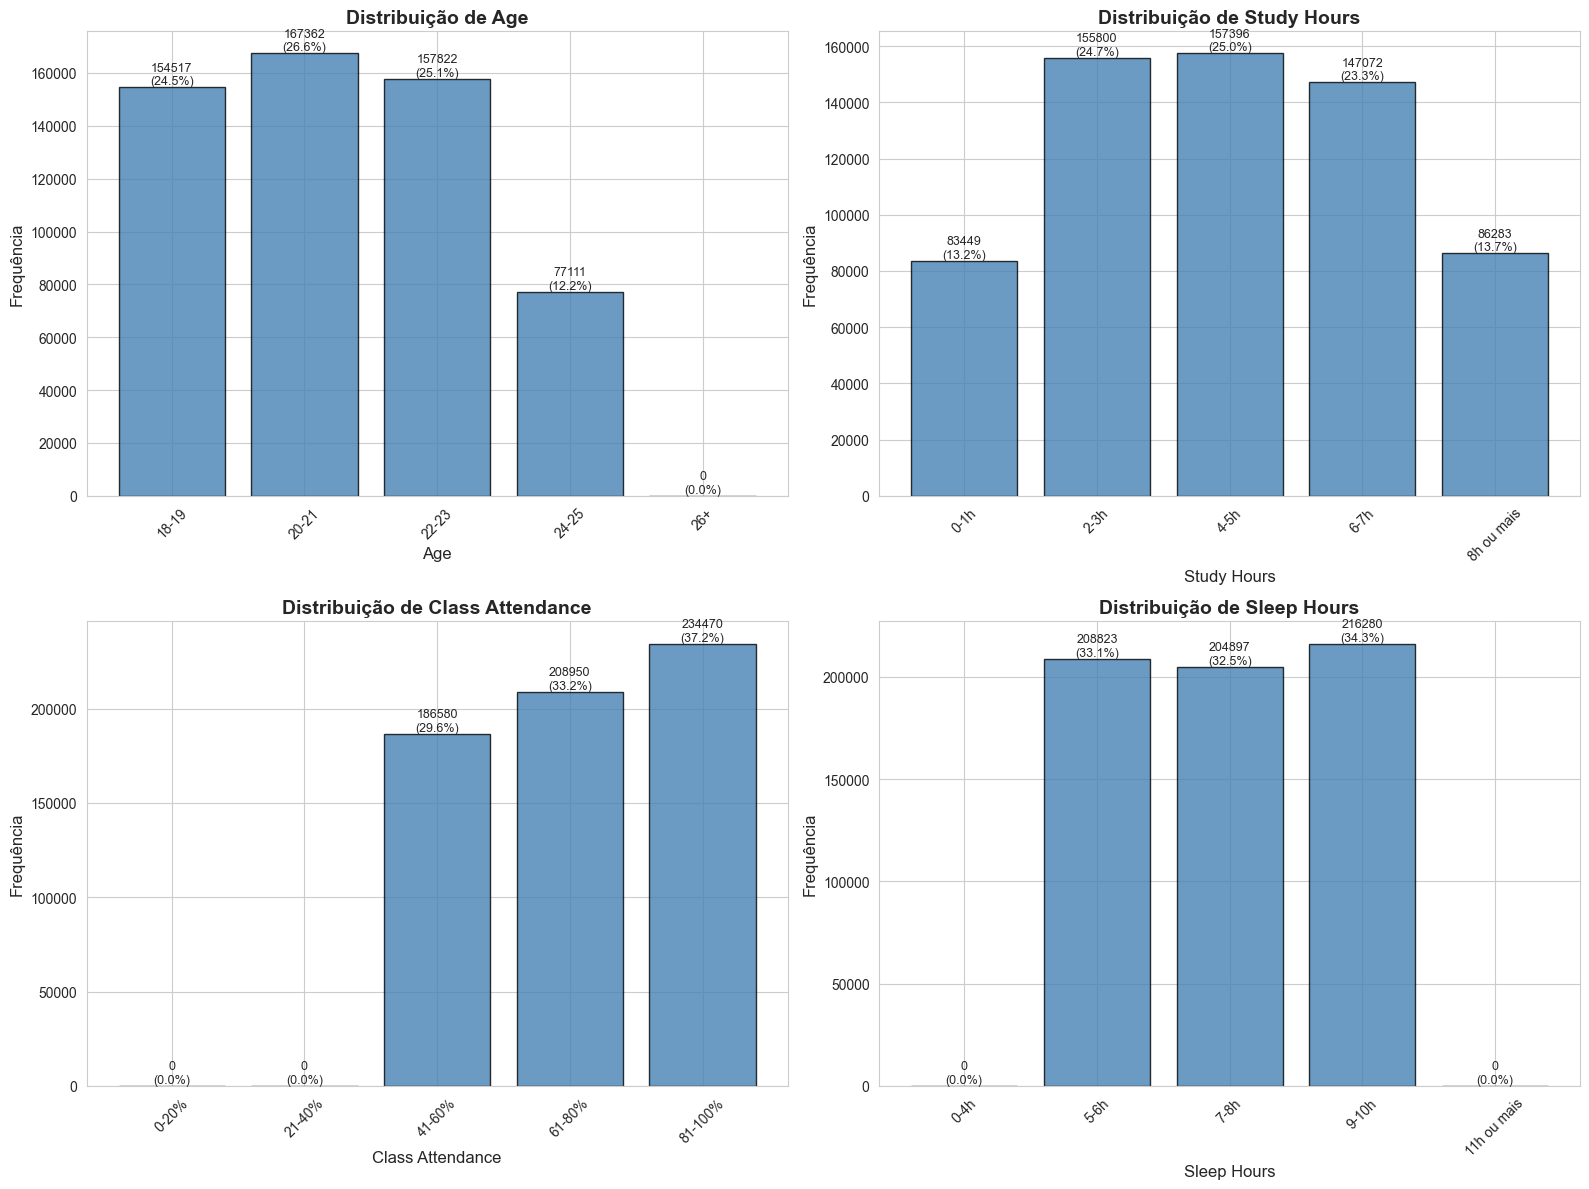

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Lista das variáveis intervalares (excluindo exam_score_interval)
interval_vars = [
    'age_interval', 
    'study_hours_interval', 
    'class_attendance_interval',
    'sleep_hours_interval'
]

# Criar subplots para visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(interval_vars):
    # Calcular contagens e percentagens
    counts = data_intervals[var].value_counts().sort_index()
    percentages = (counts / len(data_intervals)) * 100
    
    # Gráfico de barras
    bars = axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.8)
    
    # Título sem a palavra "interval"
    title = var.replace('_interval', '').replace('_', ' ').title()
    axes[i].set_title(f'Distribuição de {title}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(title, fontsize=12)
    axes[i].set_ylabel('Frequência', fontsize=12)
    
    # Adicionar percentagens no topo das barras
    for bar, count, pct in zip(bars, counts.values, percentages.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                    f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    
    # Rotacionar labels do eixo x se necessário
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Pré processamento

Passos comuns a todas as etapas

In [19]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

### Pré processamento para regressão


In [20]:
# remover os outliers
outliers_index = lof_df[lof_df["outlier"] == -1].index
data_reg = data.copy()
data_reg = data.drop(index = outliers_index)
#print(len(data_reg))
data_reg_cat = data_reg.copy()
data_reg_cat["internet_access"] = data_reg_cat["internet_access"].str.strip().str.lower().map({"yes":1, "no":0})
print(data_reg_cat)

        age  gender  course  study_hours  class_attendance  internet_access  \
3        19    male    b.sc         2.00              49.5                1   
4        23    male     bca         7.65              86.9                1   
5        24    male   b.com         5.04              85.1                1   
6        20    male    b.sc         4.28              87.0                0   
7        22  female      ba         4.19              44.9                1   
...     ...     ...     ...          ...               ...              ...   
629994   20    male   b.com         1.67              73.7                1   
629995   18  female  b.tech         4.86              70.7                1   
629996   21  female      ba         7.08              54.4                1   
629997   24    male     bca         0.64              44.2                1   
629998   20    male   b.com         1.54              75.1                1   

        sleep_hours sleep_quality   study_method fa

para variáveis categóricas com ordem

In [21]:
# sleep_quality facility_rating
print(data_reg_cat["sleep_quality"].unique())
print(data_reg_cat["facility_rating"].unique())
print(data_reg_cat["exam_difficulty"].unique())  # se aplicar exam_map

['average' 'good' 'poor']
['high' 'medium' 'low']
['moderate' 'easy' 'hard']


In [22]:
data_reg_cat["sleep_quality_clean"] = (
    data_reg_cat["sleep_quality"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data_reg_cat["facility_rating_clean"] = (
    data_reg_cat["facility_rating"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data_reg_cat["exam_difficulty_clean"] = (
    data_reg_cat["exam_difficulty"]
    .astype(str)
    .str.strip()
    .str.lower()
)


sleep_map = {"poor": 0, "average": 1, "good": 2}
facility_map = {"low": 0, "medium": 1, "high": 2}
exam_map = {"easy": 0, "moderate": 1, "hard": 2}

data_reg_cat["sleep_quality_mapped"] = data_reg_cat["sleep_quality_clean"].map(sleep_map)
data_reg_cat["facility_rating_mapped"] = data_reg_cat["facility_rating_clean"].map(facility_map)
data_reg_cat["exam_difficulty_mapped"] = data_reg_cat["exam_difficulty_clean"].map(exam_map)

data_reg_cat["sleep_quality_mapped"] = data_reg_cat["sleep_quality_mapped"].fillna(-1)
data_reg_cat["facility_rating_mapped"] = data_reg_cat["facility_rating_mapped"].fillna(-1)
data_reg_cat["exam_difficulty_mapped"] = data_reg_cat["exam_difficulty_mapped"].fillna(-1)

print(
    data_reg_cat[
        [
            "sleep_quality", "sleep_quality_mapped",
            "facility_rating", "facility_rating_mapped",
            "exam_difficulty", "exam_difficulty_mapped"
        ]
    ].head()
)

  sleep_quality  sleep_quality_mapped facility_rating  facility_rating_mapped  \
3       average                     1            high                       2   
4          good                     2            high                       2   
5       average                     1          medium                       1   
6       average                     1            high                       2   
7          good                     2            high                       2   

  exam_difficulty  exam_difficulty_mapped  
3        moderate                       1  
4            easy                       0  
5        moderate                       1  
6        moderate                       1  
7            hard                       2  


In [23]:
# colunas mapeadas
cols_mapped = [col for col in data_reg_cat.columns if col.endswith("_mapped")]

# colunas que NÃO sofreram alterações (exclui as _clean)
cols_original = [col for col in data_reg_cat.columns if not col.endswith("_clean") and not col.endswith("_mapped")]

# novo dataframe final
data_reg_final = data_reg_cat[cols_original + cols_mapped]
data_reg_final = data_reg_final.drop(columns=["sleep_quality", "facility_rating","exam_difficulty"])
data_reg_final.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,study_method,exam_score,sleep_quality_mapped,facility_rating_mapped,exam_difficulty_mapped
3,19,male,b.sc,2.00,49.5,1,8.3,group study,63.9,1,2,1
4,23,male,bca,7.65,86.9,1,9.6,self-study,100.0,2,2,0
5,24,male,b.com,5.04,85.1,1,9.4,online videos,70.1,1,1,1
6,20,male,b.sc,4.28,87.0,0,9.1,mixed,63.4,1,2,1
7,22,female,ba,4.19,44.9,1,8.8,self-study,76.8,2,2,2


In [24]:
# limpar
data_reg_cat["study_method_clean"] = (
    data_reg_cat["study_method"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# one-hot encoding (com drop_first)
study_dummies = pd.get_dummies(
    data_reg_cat["study_method_clean"],
    prefix="study_method",
    drop_first=True
).astype(int)

course_dummies = pd.get_dummies(
    data_reg_cat["course"],
    prefix="course",
    drop_first=True
).astype(int)

# juntar
data_reg_final = pd.concat(
    [data_reg_final, study_dummies, course_dummies],
    axis=1
)
# limpar
data_reg_cat["gender_clean"] = (
    data_reg_cat["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# one-hot encoding
gender_dummies = pd.get_dummies(
    data_reg_cat["gender_clean"],
    prefix="gender",
    drop_first=True
).astype(int)

# juntar ao dataframe final
data_reg_final = pd.concat(
    [data_reg_final, gender_dummies],
    axis=1
)

# remover coluna original
data_reg_final = data_reg_final.drop(
    columns=["gender"],
    errors="ignore"
)

data_reg_final.head()

data_reg_final.describe()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,sleep_quality_mapped,facility_rating_mapped,exam_difficulty_mapped,study_method_group study,...,study_method_online videos,study_method_self-study,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,gender_male,gender_other
count,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,...,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000,598500.000000
mean,20.546468,4.009131,72.064617,0.919684,7.073758,62.572685,1.000149,0.984927,0.877519,0.196837,...,0.192581,0.207352,0.177133,0.208573,0.098232,0.119753,0.140665,0.078949,0.334508,0.335033
std,2.258987,2.360262,17.349004,0.271782,1.736774,18.641635,0.820929,0.811078,0.650715,0.397608,...,0.394327,0.405410,0.381781,0.406289,0.297629,0.324672,0.347676,0.269659,0.471819,0.472002
min,17.000000,0.080000,40.600000,0.000000,4.100000,19.599000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.970000,57.200000,1.000000,5.600000,49.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.000000,4.010000,72.600000,1.000000,7.100000,62.600000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,23.000000,6.060000,87.200000,1.000000,8.600000,76.100000,2.000000,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,24.000000,7.910000,99.400000,1.000000,9.900000,100.000000,2.000000,2.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


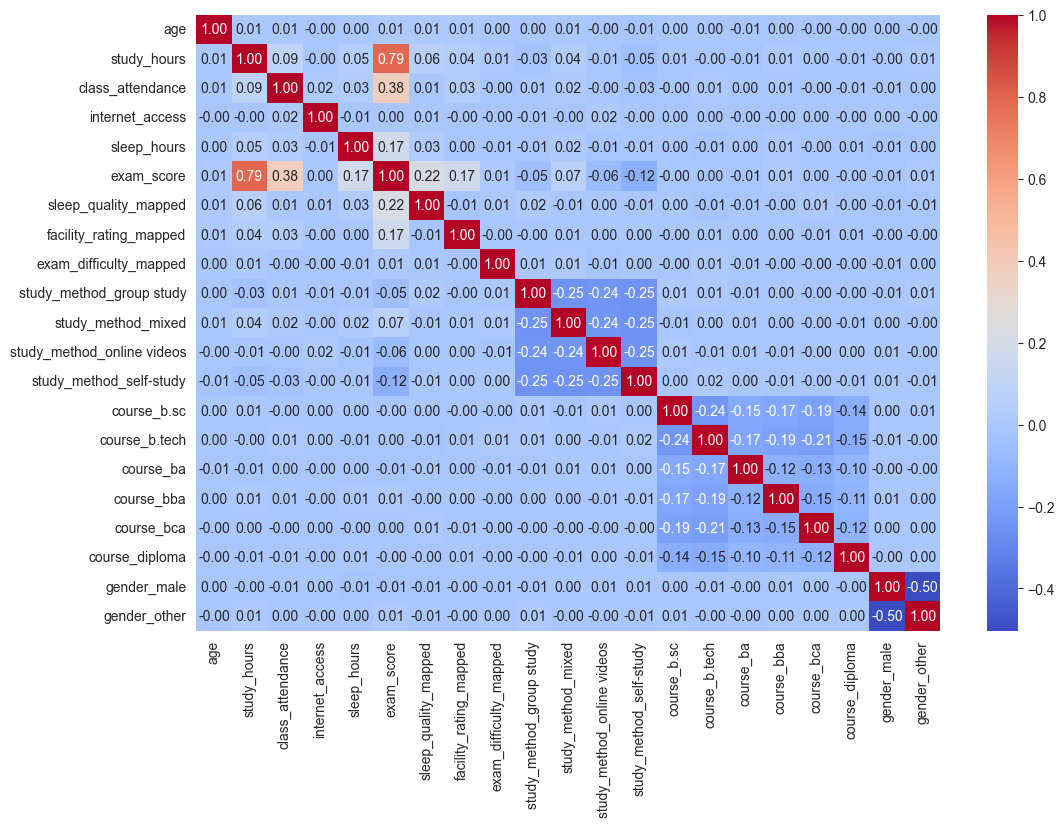

In [25]:
numeric_cols = data_reg_final.select_dtypes(include=["float64", "int64"]).columns
corr = data_reg_final[numeric_cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

Verificação do VIF

In [26]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# copiar dataframe
df2 = data_reg_final.copy()

# manter apenas variáveis numéricas
df_num = df2.select_dtypes(include=['number'])

# adicionar constante
X = sm.add_constant(df_num)

# calcular VIF
vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

print(vif_df)

                      Variável         VIF
0                        const  143.627780
1                          age    1.000447
2                  study_hours    3.765584
3             class_attendance    1.457900
4              internet_access    1.000725
5                  sleep_hours    1.083751
6                   exam_score    5.109168
7         sleep_quality_mapped    1.154372
8       facility_rating_mapped    1.098931
9       exam_difficulty_mapped    1.000935
10    study_method_group study    1.667896
11          study_method_mixed    1.608533
12  study_method_online videos    1.683306
13     study_method_self-study    1.748642
14                 course_b.sc    1.648912
15               course_b.tech    1.728065
16                   course_ba    1.403699
17                  course_bba    1.477555
18                  course_bca    1.543748
19              course_diploma    1.333121
20                 gender_male    1.340443
21                gender_other    1.340415


### Criação de atributos

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = data_reg_final.copy()

df["total_study_time"] = df["study_hours"] + df["class_attendance"]

df["sleep_balance"] = df["sleep_hours"] * df["sleep_quality_mapped"]

df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1) # +1 para evitar soma por zero

df["log_study_hours"] = np.log1p(df["study_hours"])

df["study_hours_squared"] = df["study_hours"] ** 2

df["study_attendance_interaction"] = df["study_hours"] * df["class_attendance"]

df["sleep_quality_effect"] = df["sleep_hours"] * df["sleep_quality_mapped"]

df["study_vs_sleep"] = df["study_hours"] / (df["sleep_hours"] + 1)

#remoção da coluna age
df = df.drop(columns=["age"])

# regressão: class_attendance ~ study_hours
X = sm.add_constant(df["study_hours"])
y = df["class_attendance"]
model = sm.OLS(y, X).fit()

#criação da nova variável e remoção da variável anterior
df["attendance_residual"] = model.resid
df = df.drop(columns=["class_attendance"])

df["study_effort"] = df["study_hours"] * df["attendance_residual"]
df["rest_balance"] = df["sleep_hours"] * df["sleep_quality_mapped"]
df["study_difficulty"] = df["study_hours"] * df["exam_difficulty_mapped"]

Verificar novamente VIF

In [28]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# copiar dataframe
df2 = df.copy()

# manter apenas variáveis numéricas
df_num = df2.select_dtypes(include=['number'])

# adicionar constante
X = sm.add_constant(df_num)

# calcular VIF
vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i)
                 for i in range(X.shape[1])]

print(vif_df)

C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                        Variável         VIF
0                          const    0.000000
1                    study_hours         inf
2                internet_access    1.000839
3                    sleep_hours    4.932912
4                     exam_score    5.113525
5           sleep_quality_mapped   17.636541
6         facility_rating_mapped    1.098996
7         exam_difficulty_mapped    3.886627
8       study_method_group study    1.668406
9             study_method_mixed    1.609602
10    study_method_online videos    1.683520
11       study_method_self-study    1.748659
12                   course_b.sc    1.649567
13                 course_b.tech    1.729086
14                     course_ba    1.403863
15                    course_bba    1.477666
16                    course_bca    1.543839
17                course_diploma    1.333168
18                   gender_male    1.340520
19                  gender_other    1.340599
20              total_study_time         inf
21        

Valores Significativos na correlação abs maior que 0.1

In [29]:
corr = df.corr(numeric_only=True)
corr_exam = corr["exam_score"]

selected_features = corr_exam[corr_exam.abs() >= 0.1].index
selected_features = selected_features.drop("exam_score", errors="ignore")

df_final = df[list(selected_features) + ["exam_score"]]

df_final.head()

,study_hours,sleep_hours,sleep_quality_mapped,facility_rating_mapped,study_method_self-study,total_study_time,sleep_balance,study_sleep_ratio,log_study_hours,study_hours_squared,study_attendance_interaction,sleep_quality_effect,study_vs_sleep,attendance_residual,study_effort,rest_balance,study_difficulty,exam_score
3,2.00,8.3,1,2,0,51.50,8.3,0.215054,1.098612,4.0000,99.000,8.3,0.215054,-21.178643,-42.357287,8.3,2.00,63.9
4,7.65,9.6,2,2,1,94.55,19.2,0.721698,2.157559,58.5225,664.785,19.2,0.721698,12.323775,94.276881,19.2,0.00,100.0
5,5.04,9.4,1,1,0,90.14,9.4,0.484615,1.798404,25.4016,428.904,9.4,0.484615,12.324251,62.114224,9.4,5.04,70.1
6,4.28,9.1,1,2,0,91.28,9.1,0.423762,1.663926,18.3184,372.360,9.1,0.423762,14.748527,63.123697,9.1,4.28,63.4
7,4.19,8.8,2,2,1,49.09,17.6,0.427551,1.646734,17.5561,188.131,17.6,0.427551,-27.289387,-114.342533,17.6,8.38,76.8


Normalização

In [30]:
from sklearn.preprocessing import StandardScaler

df_numeric = df.select_dtypes(include=["int64", "float64"])

scaler = StandardScaler()
df_normal = scaler.fit_transform(df_numeric)

df_normal = pd.DataFrame(df_normal, columns=df_numeric.columns)

In [31]:
print(df_normal.columns)

Index(['study_hours', 'internet_access', 'sleep_hours', 'exam_score',
       'sleep_quality_mapped', 'facility_rating_mapped',
       'exam_difficulty_mapped', 'study_method_group study',
       'study_method_mixed', 'study_method_online videos',
       'study_method_self-study', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma', 'gender_male',
       'gender_other', 'total_study_time', 'sleep_balance',
       'study_sleep_ratio', 'log_study_hours', 'study_hours_squared',
       'study_attendance_interaction', 'sleep_quality_effect',
       'study_vs_sleep', 'attendance_residual', 'study_effort', 'rest_balance',
       'study_difficulty'],
      dtype='object')


Salvar *df_normal*

In [32]:
df_normal.to_parquet("df_normal.parquet")

Dividir dados treino teste nao dividir

diminuir tamanho amostra

In [33]:
from sklearn.model_selection import train_test_split

X = df_normal

X_train, X_test = train_test_split(
    X, 
    test_size=0.2,   # 20 teste
    random_state=42
)

print(X_train.shape, X_test.shape)

(478800, 31) (119700, 31)


# Segmentação

## Redução de Dimensionalidade PCA

In [34]:
from sklearn.decomposition import PCA
# escolher o número de componentes
# número de componentes é hiperparâmetro
X = df_normal.copy()
X_num = X.select_dtypes(include=["int64", "float64"])
pca = PCA()
pca.fit(X_num)

# calcular a variância acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Gráfico da Variância acumulada

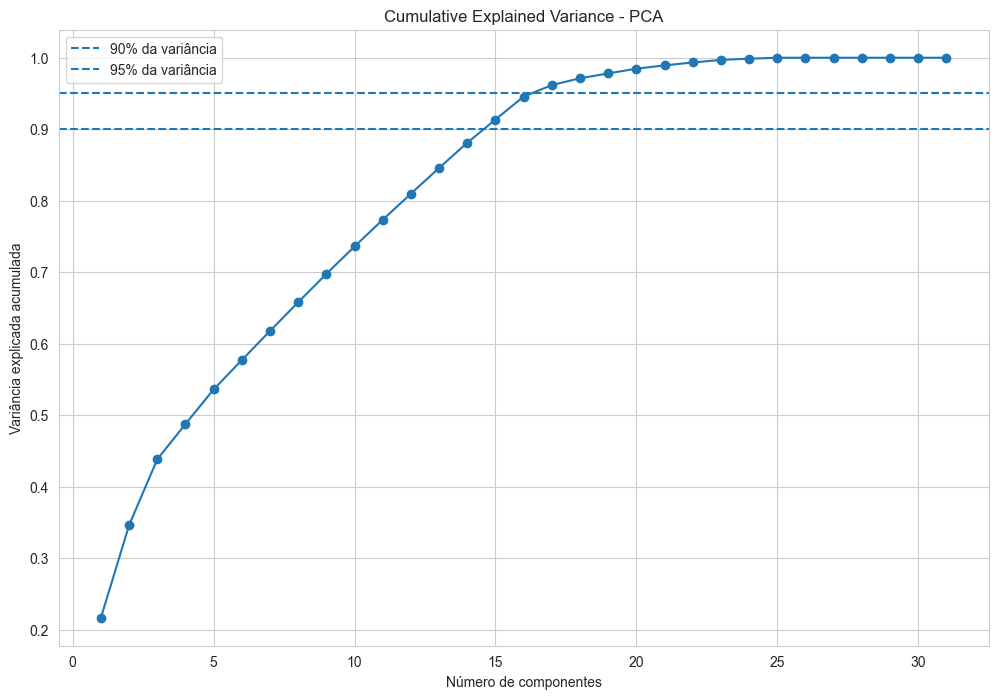

In [35]:
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.90, linestyle='--', label='90% da variância')
plt.axhline(y=0.95, linestyle='--', label='95% da variância')
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("Cumulative Explained Variance - PCA")
plt.legend()
plt.show()

Escolher 15 como número de componentes

In [36]:
pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_num)
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(15)]
)

import joblib
joblib.dump(pca, "Modelos/pca_model.pkl")

['Modelos/pca_model.pkl']

Perde interpetabilidade do modelo

K-Means
* Número de clusters com método do cotovelo

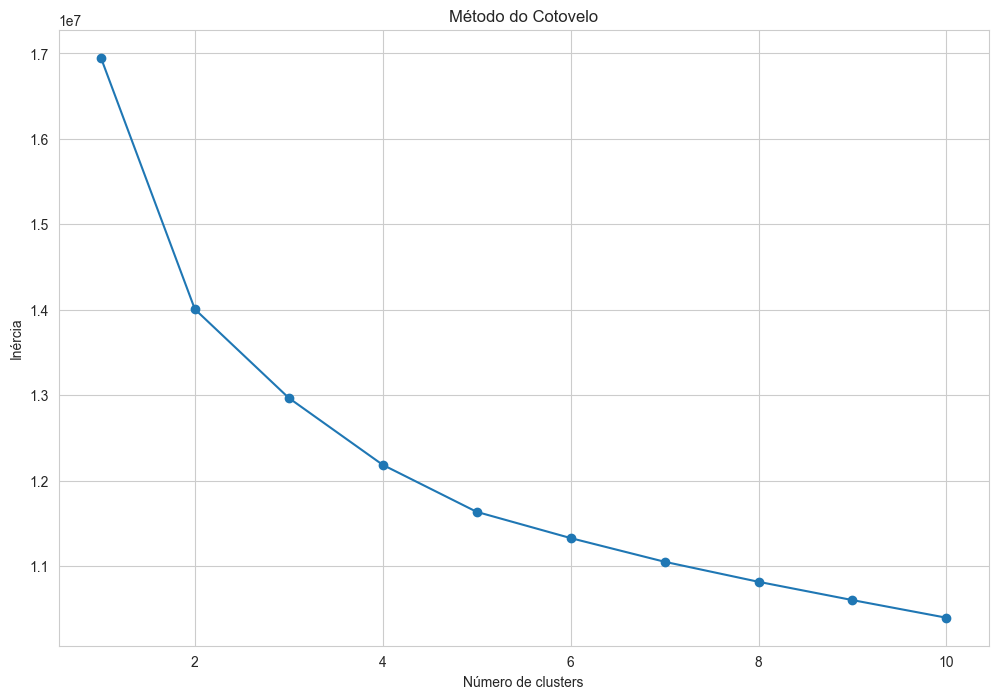

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Usar apenas as componentes PCA, sem a coluna cluster caso já exista
X_cluster = df_pca
# Lista para guardar a inércia
inertia = []
k_range = range(1, 11) # valores para cluster

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Gráfico do cotovelo
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_pca["cluster"] = kmeans.fit_predict(X_cluster)

import joblib
kmeans = joblib.dump(kmeans, "Modelos/pca_kmeans.pkl")

In [39]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,cluster
0,-2.257457,0.748879,-1.237567,-0.324660,-1.300022,0.098703,-1.593037,1.479937,-1.609421,1.623033,0.241095,1.145832,0.030688,-0.304704,1.312916,1
1,3.895184,3.438546,1.290116,-2.543704,-0.631285,-0.557603,1.398011,-1.006873,-1.401477,-1.838981,-0.301251,2.223057,-0.291197,-0.381510,0.917416,0
2,1.152488,0.740041,1.236989,-0.372357,-1.500906,0.338238,-1.119143,-1.230531,1.178696,0.112535,0.925599,1.126438,0.029113,-0.272831,-0.314885,0
3,0.533083,0.679076,1.451614,-0.199978,-1.524969,2.256649,0.174990,-0.119328,-1.369448,2.061814,-0.455438,0.614069,-0.119861,-0.052141,1.136469,0
4,0.153185,3.218323,-2.756783,1.816891,-0.904589,-0.457433,1.175720,-1.271339,-1.002004,-0.553738,1.047535,-0.328365,2.799720,-1.228649,1.336953,1


In [40]:
df_pca["cluster"].value_counts()

cluster
2    169627
0    154494
1    149046
3    125333
Name: count, dtype: int64

Métricas K-means PCA

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# labels clusters
labels = df_pca["cluster"]

silhouette = silhouette_score(X_cluster, labels)
davies = davies_bouldin_score(X_cluster, labels)
calinski = calinski_harabasz_score(X_cluster, labels)


#inertia = kmeans.inertia_

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Score: {calinski:.4f}")
#print(f"Inércia: {inertia:.4f}")

K-Means sem pca

In [43]:
X_means = df_normal.copy()

Visualização dos Cluster T-SNE 

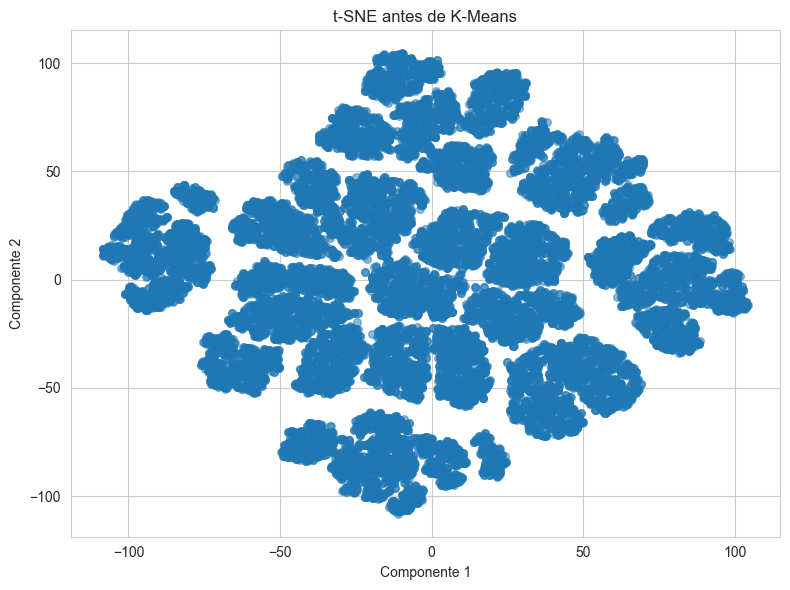

In [45]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Fazer sample dos dados
X_sample = X_means.sample(
    n=20000,          
    random_state=42
)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    alpha=0.5,
    s=30
)

plt.title('t-SNE antes de K-Means')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')

plt.tight_layout()
plt.show()

Fit modelo k-means

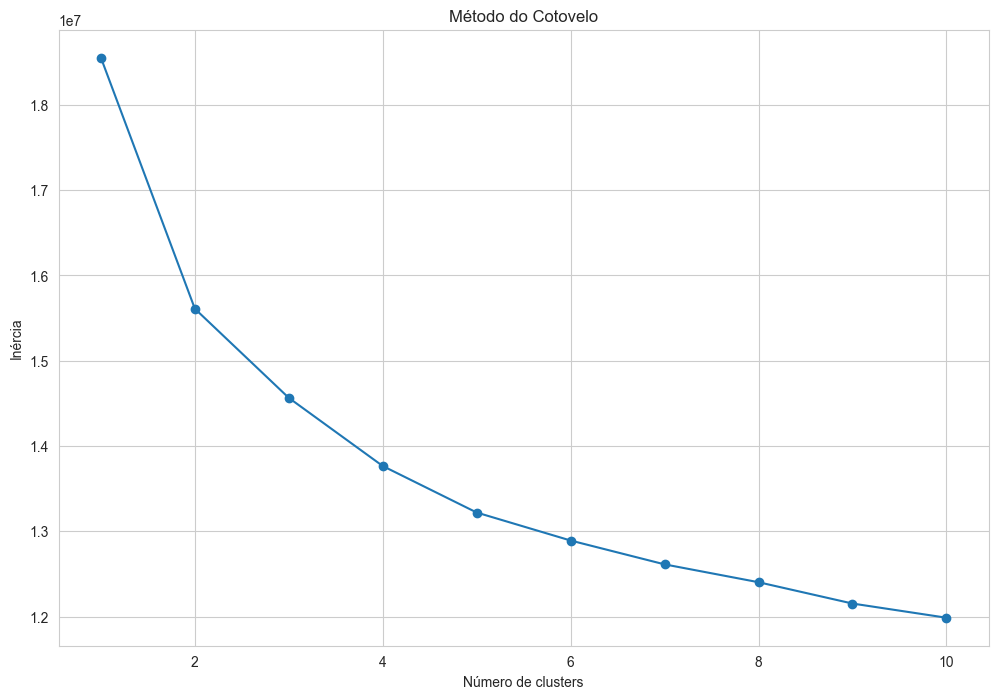

In [46]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
# Lista para guardar a inércia
inertia = []
k_range = range(1, 11) # valores para cluster

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_means)
    inertia.append(kmeans.inertia_)

# Gráfico do cotovelo
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_means["cluster"] = kmeans.fit_predict(X_means)

import joblib

kmeans = joblib.dump(kmeans, "Modelos/kmeans_sem_pca.pkl")

Métrica K-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import matplotlib.pyplot as plt
import pandas as pd

X_arv = X_means.drop("cluster", axis=1)

silhouette = silhouette_score(X_arv, X_means["cluster"])
davies = davies_bouldin_score(X_arv, X_means["cluster"])
calinski = calinski_harabasz_score(X_arv, X_means["cluster"])
inertia = kmeans.inertia_
 
print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", davies)
print("Calinski-Harabasz Score:", calinski)
print("Inércia:", inertia)

Interpretar modelo

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X_k = X_means.drop("cluster", axis=1)
y_k = X_means["cluster"]

tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=1000,
    random_state=42
)

# Treinar a árvore com os clusters do KMeans
tree.fit(X_k, y_k)

# Prever os próprios clusters
y_pred = tree.predict(X_k)

# Métricas da árvore
print("\nMétricas da Árvore de Decisão:")
print("Accuracy:", accuracy_score(y_k, y_pred))

print("\nClassification Report:")
print(classification_report(y_k, y_pred))

import joblib

tree_kmeans = joblib.dump(tree,"Modelos/arvore_kmeans_sem_pca.pkl")


Métricas da Árvore de Decisão:
Accuracy: 0.938578111946533

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94    169751
           1       0.91      0.94      0.92    124705
           2       0.95      0.92      0.94    150612
           3       0.95      0.96      0.95    153432

    accuracy                           0.94    598500
   macro avg       0.94      0.94      0.94    598500
weighted avg       0.94      0.94      0.94    598500



In [ ]:
cm = confusion_matrix(y_k, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tree.classes_
)
disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

NameError: name 'confusion_matrix' is not defined

In [ ]:
# importancia das variáveis

feature_importance = pd.DataFrame({
    "Variável": X_k.columns,
    "Importância": tree.feature_importances_
}).sort_values(by="Importância", ascending=False)

print(feature_importance)

                        Variável  Importância
20                 sleep_balance     0.332406
19              total_study_time     0.293921
23           study_hours_squared     0.291401
24  study_attendance_interaction     0.027509
26                study_vs_sleep     0.018222
29                  rest_balance     0.017072
25          sleep_quality_effect     0.010895
21             study_sleep_ratio     0.006654
28                  study_effort     0.001920
1                internet_access     0.000000
0                    study_hours     0.000000
3                     exam_score     0.000000
4           sleep_quality_mapped     0.000000
5         facility_rating_mapped     0.000000
2                    sleep_hours     0.000000
14                    course_bba     0.000000
13                     course_ba     0.000000
12                 course_b.tech     0.000000
11                   course_b.sc     0.000000
10       study_method_self-study     0.000000
9     study_method_online videos  

Árvore de decisão

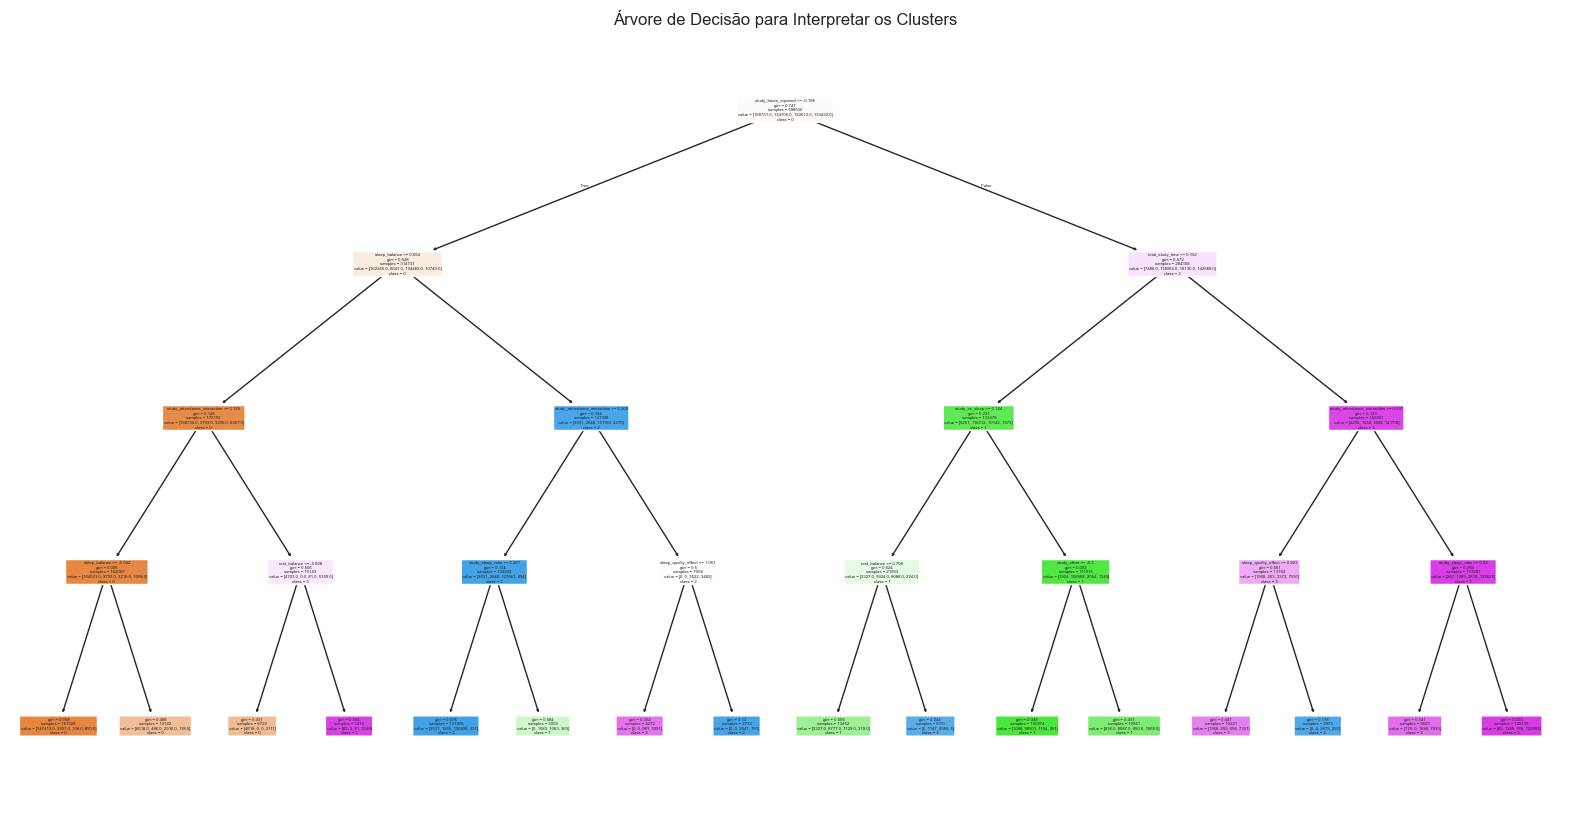

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=X_k.columns,
    class_names=[str(c) for c in tree.classes_],
    filled=True,
    rounded=True
)

plt.title("Árvore de Decisão para Interpretar os Clusters")
plt.show()

Clustering por densidade


* DBSCAN não precisa de configurar número de clusters

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dados normalizados
X_db = df_normal.copy()

# Se existir alguma coluna de cluster anterior, remover
X_db = X_db.drop("cluster", axis=1, errors="ignore")
X_db = X_db.drop("cluster_dbscan", axis=1, errors="ignore")

# Amostra porque tens muitos dados
X_db_amostra = X_db.sample(n=80000, random_state=42)

# Testar vários valores de eps
eps_values = [0.2, 0.5, 0.8, 1, 1.5, 2, 3, 4, 5]

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        n_jobs=-1
    )

    labels_dbscan = dbscan.fit_predict(X_db_amostra)

    n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_outliers = list(labels_dbscan).count(-1)

    print("eps:", eps)
    print("Número de clusters:", n_clusters)
    print("Número de outliers:", n_outliers)
    print("Percentagem de outliers:", round(n_outliers / len(labels_dbscan) * 100, 2), "%")
    print("-" * 40)
    
# escolher ep=3

eps: 0.2
Número de clusters: 0
Número de outliers: 80000
Percentagem de outliers: 100.0 %
----------------------------------------
eps: 0.5
Número de clusters: 0
Número de outliers: 80000
Percentagem de outliers: 100.0 %
----------------------------------------
eps: 0.8
Número de clusters: 0
Número de outliers: 80000
Percentagem de outliers: 100.0 %
----------------------------------------
eps: 1
Número de clusters: 0
Número de outliers: 80000
Percentagem de outliers: 100.0 %
----------------------------------------
eps: 1.5
Número de clusters: 110
Número de outliers: 78481
Percentagem de outliers: 98.1 %
----------------------------------------
eps: 2
Número de clusters: 442
Número de outliers: 42055
Percentagem de outliers: 52.57 %
----------------------------------------
eps: 3
Número de clusters: 36
Número de outliers: 3511
Percentagem de outliers: 4.39 %
----------------------------------------
eps: 4
Número de clusters: 1
Número de outliers: 15
Percentagem de outliers: 0.02 %
---

In [ ]:
from sklearn.cluster import DBSCAN

dbscan_final = DBSCAN(
    eps=3.3,
    min_samples=10,
    n_jobs=-1
)

labels_dbscan = dbscan_final.fit_predict(X_db_amostra)

df_dbscan_f = X_db_amostra.copy()
df_dbscan_f["cluster_dbscan"] = labels_dbscan

print(df_dbscan_f["cluster_dbscan"].value_counts())

import joblib
dbscan_modelo =joblib.dump(dbscan_final, "Modelos/dbscan_final.pkl") 

cluster_dbscan
 0    60644
 2     7204
 1     5735
 3     4530
-1     1315
 4      366
 5       95
 7       86
 6       17
 8        8
Name: count, dtype: int64


Métricas DBSCAN

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Variáveis
X_db_metricas = df_dbscan_f.drop("cluster_dbscan", axis=1)
y_db_metricas = df_dbscan_f["cluster_dbscan"]

# Número de clusters, ignorando outliers (-1)
n_clusters = len(set(y_db_metricas)) - (1 if -1 in y_db_metricas.values else 0)

# Número de outliers
n_outliers = (y_db_metricas == -1).sum()

# Percentagem de outliers
perc_outliers = n_outliers / len(y_db_metricas) * 100

print("Métricas gerais do DBSCAN:")
print("Número de clusters:", n_clusters)
print("Número de outliers:", n_outliers)
print("Percentagem de outliers:", round(perc_outliers, 2), "%")

print("\nNúmero de elementos por cluster:")
print(y_db_metricas.value_counts())

Métricas gerais do DBSCAN:
Número de clusters: 9
Número de outliers: 1315
Percentagem de outliers: 1.64 %

Número de elementos por cluster:
cluster_dbscan
 0    60644
 2     7204
 1     5735
 3     4530
-1     1315
 4      366
 5       95
 7       86
 6       17
 8        8
Name: count, dtype: int64


In [ ]:
# Remover outliers para calcular métricas
mask = y_db_metricas != -1

X_sem_outliers = X_db_metricas.loc[mask]
y_sem_outliers = y_db_metricas.loc[mask]

# Só dá para calcular métricas se existirem pelo menos 2 clusters
if len(set(y_sem_outliers)) >= 2:

    silhouette = silhouette_score(
        X_sem_outliers,
        y_sem_outliers,
        sample_size=min(3000, len(X_sem_outliers)),
        random_state=42
    )

    davies = davies_bouldin_score(X_sem_outliers, y_sem_outliers)
    calinski = calinski_harabasz_score(X_sem_outliers, y_sem_outliers)

    print("\nMétricas de qualidade do DBSCAN:")
    print("Silhouette Score:", silhouette)
    print("Davies-Bouldin Score:", davies)
    print("Calinski-Harabasz Score:", calinski)

else:
    print("\nO DBSCAN não criou clusters suficientes para calcular Silhouette, Davies-Bouldin e Calinski-Harabasz.")


Métricas de qualidade do DBSCAN:
Silhouette Score: 0.03917207405507666
Davies-Bouldin Score: 2.401896704845784
Calinski-Harabasz Score: 1049.3197374387119


## Clustering Hierárquico

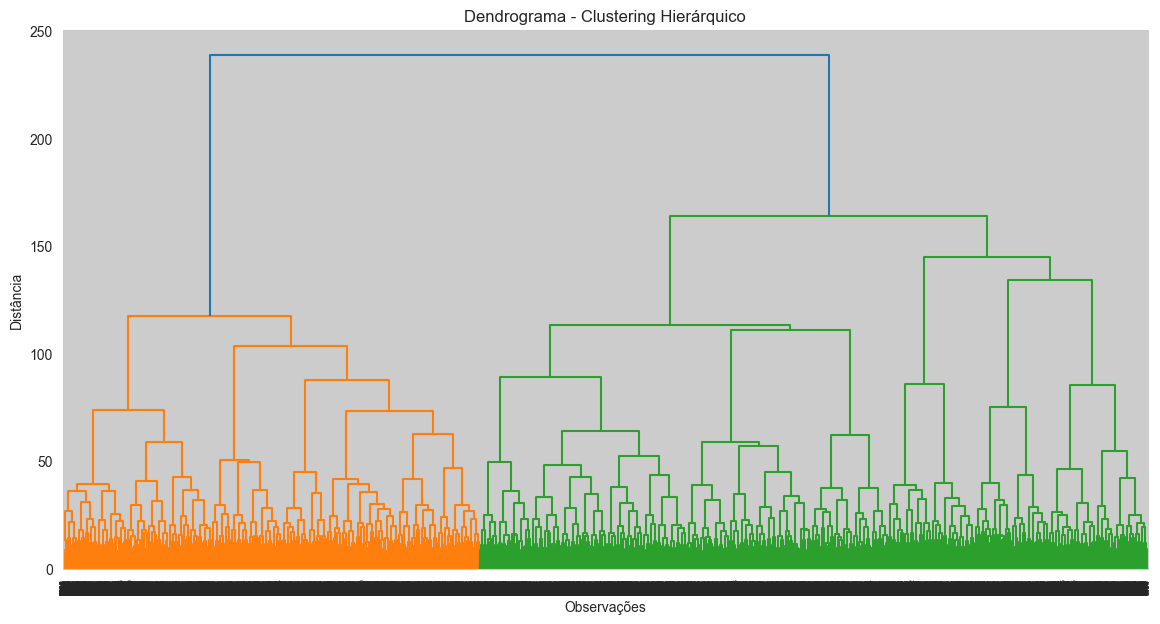

In [ ]:
X_hier = df_normal.copy()
X_h_amostra = X_hier.sample(n=10000, random_state=42)

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Linkage hierárquico
linked = linkage(X_h_amostra, method="ward") # utilizar average

plt.figure(figsize=(14, 7))
dendrogram(linked)
plt.title("Dendrograma - Clustering Hierárquico")
plt.xlabel("Observações")
plt.ylabel("Distância")
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import matplotlib.pyplot as plt
import pandas as pd

hierarquico = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_h = hierarquico.fit_predict(X_h_amostra)

# Guardar clusters
df_hierarquico = X_h_amostra.copy()
df_hierarquico["cluster_hierarquico"] = labels_h

print("Número de elementos por cluster:")
print(df_hierarquico["cluster_hierarquico"].value_counts())

# Métricas
X_metricas_h = df_hierarquico.drop("cluster_hierarquico", axis=1)
y_metricas_h = df_hierarquico["cluster_hierarquico"]

silhouette_h = silhouette_score(
    X_metricas_h,
    y_metricas_h,
    sample_size=min(3000, len(X_metricas_h)),
    random_state=42
)

davies_h = davies_bouldin_score(X_metricas_h, y_metricas_h)
calinski_h = calinski_harabasz_score(X_metricas_h, y_metricas_h)

print("\nMétricas do Clustering Hierárquico:")
print("Silhouette Score:", silhouette_h)
print("Davies-Bouldin Score:", davies_h)
print("Calinski-Harabasz Score:", calinski_h)

import joblib

hierarquico = joblib.dump(hierarquico, "Modelos/modelo_hierarquico.pkl")

Número de elementos por cluster:
cluster_hierarquico
1    3845
2    3771
0    1587
3     797
Name: count, dtype: int64

Métricas do Clustering Hierárquico:
Silhouette Score: 0.09080497085414382
Davies-Bouldin Score: 2.9105049934936793
Calinski-Harabasz Score: 676.6647485986267


Interpretação do Clustering hierárquico

In [ ]:
perfil_clusters = df_hierarquico.groupby("cluster_hierarquico").mean()

print(perfil_clusters)

                     study_hours  internet_access  sleep_hours  exam_score  \
cluster_hierarquico                                                          
0                      -0.021296        -1.294961     0.003790   -0.059047   
1                       0.808859         0.277334    -0.030429    0.650158   
2                      -0.780032         0.292589     0.066443   -0.629064   
3                      -0.028593        -0.064578     0.014532   -0.036806   

                     sleep_quality_mapped  facility_rating_mapped  \
cluster_hierarquico                                                 
0                               -0.065425               -0.010161   
1                                0.083773                0.007040   
2                               -0.045728               -0.046480   
3                               -0.016994                0.003114   

                     exam_difficulty_mapped  study_method_group study  \
cluster_hierarquico                        

In [ ]:
for cluster in perfil_clusters.index:
    print(f"\nCluster {cluster}")
    
    print("\nVariáveis mais acima da média:")
    print(perfil_clusters.loc[cluster].sort_values(ascending=False).head(5))
    
    print("\nVariáveis mais abaixo da média:")
    print(perfil_clusters.loc[cluster].sort_values(ascending=True).head(5))


Cluster 0

Variáveis mais acima da média:
course_ba                  1.757446
gender_male                0.046924
study_method_self-study    0.023210
exam_difficulty_mapped     0.016828
study_method_mixed         0.010618
Name: 0, dtype: float64

Variáveis mais abaixo da média:
internet_access   -1.294961
course_diploma    -0.292773
course_b.tech     -0.276072
course_b.sc       -0.265908
course_bca        -0.230599
Name: 0, dtype: float64

Cluster 1

Variáveis mais acima da média:
study_hours            0.808859
study_hours_squared    0.791996
study_sleep_ratio      0.762716
study_vs_sleep         0.762716
log_study_hours        0.758925
Name: 1, dtype: float64

Variáveis mais abaixo da média:
course_ba                    -0.330050
course_diploma               -0.292773
study_method_group study     -0.045682
study_method_self-study      -0.034814
study_method_online videos   -0.032632
Name: 1, dtype: float64

Cluster 2

Variáveis mais acima da média:
internet_access    0.292589
course

# Classificação

Mapear o exam score para variável categórica



# Modelos a usar
Logistic Regression
Decision Tree
Random Forest
KNN
SVM

In [ ]:
df_numeric["exam_score"]

3          63.900
4         100.000
5          70.100
6          63.400
7          76.800
           ...   
629994     41.700
629995     69.500
629996     78.900
629997     19.599
629998     59.100
Name: exam_score, Length: 598500, dtype: float64

In [ ]:
df_class = df_numeric.copy()

import pandas as pd

bins = [0, 50, 60, 70, 80, 90, 100]

labels = ['F', 'E', 'D', 'C', 'B', 'A']

df_class["exam_score"] = pd.cut(
    df_numeric["exam_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df_class["exam_score"].value_counts())

exam_score
F    160315
D    116876
E    107754
C    100954
B     66428
A     46173
Name: count, dtype: int64


Aplicar SMOTE para classe A e B
nos dados de treino

k-fold + separar target

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Criar classes se ainda não tiveres criado
bins = [0, 50, 60, 70, 80, 90, 100]
labels = ["F", "E", "D", "C", "B", "A"]

df_class["nota_classe"] = pd.cut(
    df_class["exam_score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Remover linhas sem classe
df_ml = df_class.dropna(subset=["nota_classe"]).copy()

# Separar X e y
X = df_ml.drop(["exam_score", "nota_classe"], axis=1, errors="ignore")
y = df_ml["nota_classe"].astype(str)

# Converter variáveis categóricas em dummies
X = pd.get_dummies(X, drop_first=True)

# Estratégia SMOTE só para A e B
def smote_ab_strategy(y_fold):
    counts = Counter(y_fold)
    target = max(counts.values())

    strategy = {}

    for classe in ["A", "B"]:
        if classe in counts and counts[classe] >= 2 and counts[classe] < target:
            strategy[classe] = target

    return strategy

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(
        sampling_strategy=smote_ab_strategy,
        random_state=42,
        k_neighbors=1
    )),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# K-Fold estratificado
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Validação cruzada com accuracy
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1
)

print("Scores de cada fold:", scores)
print("Média:", scores.mean())
print("Desvio padrão:", scores.std())

TypeError: '<' not supported between instances of 'int' and 'str'

# Regressão

Modelo de Rede Neuronal

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

df_rede = df_normal.copy()
X_rede = df_rede.drop(columns=["exam_score"], errors="ignore")
y_rede = df_rede["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Rede
rede = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=300,
    early_stopping=True,
    random_state=42
)

# Validação cruzada
resultados = cross_validate(
    rede,
    X_rede,
    y_rede,
    cv=kfold,
    scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"],
    n_jobs=-1
)

print("R2 por fold:", resultados["test_r2"])
print("R2 médio:", resultados["test_r2"].mean())

print("MAE médio:", -resultados["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80481165 0.80466158 0.80355672 0.80590583 0.80708886]
R2 médio: 0.8052049271761795
MAE médio: 0.3564230371531241
RMSE médio: 0.4413494580258891


Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

df_linear = df_normal.copy()

X_linear = df_linear.drop(columns=["exam_score"], errors="ignore")
y_linear = df_linear["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo de regressão linear
modelo_linear = LinearRegression()

# Validação Métricas
resultados_linear = cross_validate(
    modelo_linear,
    X_linear,
    y_linear,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Resultados
print("R2 por fold:", resultados_linear["test_r2"])
print("R2 médio:", resultados_linear["test_r2"].mean())

print("MAE médio:", -resultados_linear["test_neg_mean_absolute_error"].mean())

print("RMSE médio:", -resultados_linear["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80435164 0.80405045 0.80282329 0.804876   0.80598766]
R2 médio: 0.804417806351155
MAE médio: 0.3571650081458094
RMSE médio: 0.4422409702978117


### Ridge

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_ridge = df_normal.copy()

X_ridge = df_ridge.drop(columns=["exam_score"], errors="ignore")
y_ridge = df_ridge["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo Ridge Regression
modelo_ridge = Ridge(
    alpha=1.0,
    random_state=42
)

# Validação cruzada
resultados_ridge = cross_validate(
    modelo_ridge,
    X_ridge,
    y_ridge,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Resultados
print("R2 por fold:", resultados_ridge["test_r2"])
print("R2 médio:", resultados_ridge["test_r2"].mean())

print("MAE médio:", -resultados_ridge["test_neg_mean_absolute_error"].mean())

print("RMSE médio:", -resultados_ridge["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80435161 0.80405061 0.80282318 0.80487595 0.80598768]
R2 médio: 0.804417806263307
MAE médio: 0.35716486166006317
RMSE médio: 0.4422409702517949


### XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_xgb = df_normal.copy()

X_xgb = df_xgb.drop(columns=["exam_score"], errors="ignore")
y_xgb = df_xgb["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelo_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Validação 
resultados_xgb = cross_validate(
    modelo_xgb,
    X_xgb,
    y_xgb,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Resultados
print("R2 por fold:", resultados_xgb["test_r2"])
print("R2 médio:", resultados_xgb["test_r2"].mean())
print("MAE médio:", -resultados_xgb["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_xgb["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80619398 0.80586446 0.80458943 0.80628956 0.80763123]
R2 médio: 0.8061137309896178
MAE médio: 0.3562491752578262
RMSE médio: 0.44031956959808805


### Baysian Ridge Regression

In [ ]:
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_bayes = df_normal.copy()

X_bayes = df_bayes.drop(columns=["exam_score"], errors="ignore")
y_bayes = df_bayes["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo Bayesiano
modelo_bayes = BayesianRidge()

# Validação cruzada
resultados_bayes = cross_validate(
    modelo_bayes,
    X_bayes,
    y_bayes,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Métricas
print("R2 por fold:", resultados_bayes["test_r2"])
print("R2 médio:", resultados_bayes["test_r2"].mean())
print("MAE médio:", -resultados_bayes["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_bayes["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.80435145 0.80405145 0.80282254 0.80487561 0.80598775]
R2 médio: 0.804417761078102
MAE médio: 0.35716408482937523
RMSE médio: 0.4422410205119377


### KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_knn = df_normal.copy()

X_knn = df_knn.drop(columns=["exam_score"], errors="ignore")
y_knn = df_knn["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo KNN
modelo_knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance"
)

# Validação cruzada
resultados_knn = cross_validate(
    modelo_knn,
    X_knn,
    y_knn,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Métricas
print("R2 por fold:", resultados_knn["test_r2"])
print("R2 médio:", resultados_knn["test_r2"].mean())
print("MAE médio:", -resultados_knn["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_knn["test_neg_root_mean_squared_error"].mean())

R2 por fold: [0.75254614 0.75116275 0.7503704  0.75177019 0.75438261]
R2 médio: 0.7520464190371721
MAE médio: 0.39982049646319706
RMSE médio: 0.49794246095805705


## SVM

In [ ]:
from sklearn.svm import SVR # Regressão
from sklearn.model_selection import KFold, cross_validate
import pandas as pd

df_svm = df_normal.copy()

X_svm = df_svm.drop(columns=["exam_score"], errors="ignore")
y_svm = df_svm["exam_score"]

# K-Fold 5
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Modelo SVM 
modelo_svm = SVR(
    kernel="linear",   # linear, poly, rbf
    C=1.0,
    epsilon=0.1
)

# Validação cruzada
resultados_svm = cross_validate(
    modelo_svm,
    X_svm,
    y_svm,
    cv=kfold,
    scoring=[
        "r2",
        "neg_mean_absolute_error",
        "neg_root_mean_squared_error"
    ],
    n_jobs=-1
)

# Resultados 
print("R2 por fold:", resultados_svm["test_r2"])
print("R2 médio:", resultados_svm["test_r2"].mean())
print("MAE médio:", -resultados_svm["test_neg_mean_absolute_error"].mean())
print("RMSE médio:", -resultados_svm["test_neg_root_mean_squared_error"].mean())

Exception in thread ExecutorManagerThread:
Traceback (most recent call last):
  File "C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\psutil\_pswindows.py", line 692, in wrapper
    return fun(self, *args, **kwargs)
  File "C:\Users\maria\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\psutil\_pswindows.py", line 870, in kill
    return cext.proc_kill(self.pid)
           ~~~~~~~~~~~~~~^^^^^^^^^^
PermissionError: [WinError 5] Acesso negado: '(originated from OpenProcess)'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\maria\AppData\Local\Packages\PythonSoftwareFound

KeyboardInterrupt: 